In [1]:
# import numpy as np
# from sklearn.datasets import make_sparse_coded_signal
# from sklearn.decomposition import DictionaryLearning

In [2]:
# X, dictionary, code = make_sparse_coded_signal(
#     n_samples=30, n_components=15, n_features=20, n_nonzero_coefs=10,
#     random_state=42,
# )

In [3]:
# print(X.shape)

In [4]:
# X

In [5]:
# print(X)

In [6]:
# dictionary

In [7]:
# print(dictionary)

In [8]:
# dictionary.shape

In [9]:
# code

In [10]:
# dict_learner = DictionaryLearning(
#     n_components=15, transform_algorithm='lasso_lars', transform_alpha=0.1,
#     random_state=42,
# )

In [11]:
# X_transformed = dict_learner.fit_transform(X)

In [12]:
# np.mean(X_transformed == 0)

In [13]:
# print(X_transformed.shape)
# print(dict_learner.components_.shape)

In [14]:
# X_transformed

In [15]:
# X_hat = X_transformed @ dict_learner.components_
# np.mean(np.sum((X_hat - X) ** 2, axis=1) / np.sum(X ** 2, axis=1))

for nci

In [16]:
from datetime import datetime
start = datetime.now().strftime("%Y%m%d_%H%M%S")

In [17]:
import networkx as nx
from rdkit import Chem
from collections import Counter

print('Loading NCI1 dataset')

graphs = []
y = []

filepath = "datasets/NCI_full/1total-connect.sdf"

supplier = Chem.SDMolSupplier(filepath, removeHs=False)
for mol in supplier:
    if mol is None:
        continue

    G = nx.Graph()

    # Add atoms as nodes
    for atom in mol.GetAtoms():
        G.add_node(
            atom.GetIdx(),
            feature=atom.GetSymbol()   # WL uses node labels
        )

    # Add bonds as edges
    for bond in mol.GetBonds():
        G.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            bond_type=str(bond.GetBondType()),
            bond_order=bond.GetBondTypeAsDouble(),
            aromatic=bond.GetIsAromatic(),
            in_ring=bond.IsInRing(),
            conjugated=bond.GetIsConjugated(),
            stereo=str(bond.GetStereo())
        )

    # Get graph label
    # In NCI1, class label is stored as a molecule property
    label = int(float(mol.GetProp("value")))
    graphs.append(G)
    y.append(label)

print(f"Loaded {len(graphs)} graphs")

Loading NCI1 dataset


[01:58:38] Explicit valence for atom # 1 O, 3, is greater than permitted
[01:58:38] ERROR: Could not sanitize molecule ending on line 1224
[01:58:38] ERROR: Explicit valence for atom # 1 O, 3, is greater than permitted
[01:58:38] Explicit valence for atom # 4 O, 3, is greater than permitted
[01:58:38] ERROR: Could not sanitize molecule ending on line 5612
[01:58:38] ERROR: Explicit valence for atom # 4 O, 3, is greater than permitted
[01:58:38] Explicit valence for atom # 1 Cl, 2, is greater than permitted
[01:58:38] ERROR: Could not sanitize molecule ending on line 5976
[01:58:38] ERROR: Explicit valence for atom # 1 Cl, 2, is greater than permitted
[01:58:38] Explicit valence for atom # 0 Br, 2, is greater than permitted
[01:58:38] ERROR: Could not sanitize molecule ending on line 9488
[01:58:38] ERROR: Explicit valence for atom # 0 Br, 2, is greater than permitted
[01:58:38] Explicit valence for atom # 1 Cl, 2, is greater than permitted
[01:58:38] ERROR: Could not sanitize molecule 

Loaded 36640 graphs


In [18]:
from sklearn.model_selection import train_test_split

G_train, G_test, y_train, y_test = train_test_split(
    graphs, y,
    test_size=0.2,
    random_state=42
)

G_vocab_train, G_ML_train, y_vocab_train, y_ML_train = train_test_split(
    G_train, y_train,
    test_size=0.75,
    random_state=42
)

In [19]:
print(len(G_vocab_train), len(y_vocab_train))

7328 7328


In [20]:
from graph_encoders.wl import WL

wl = WL()
graph_embeddings = wl.generate_training_embeddings(G_vocab_train, y_vocab_train)

c:\Users\Graph_Data\miniconda3\envs\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


selected 6358 from the adaptive selection method


In [21]:
graph_embeddings

array([[3., 2., 0., ..., 0., 0., 0.],
       [2., 2., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [6., 0., 2., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [2., 2., 0., ..., 0., 0., 0.]])

In [22]:
from sklearn.decomposition import DictionaryLearning

dict_learner = DictionaryLearning(
    n_components=8000, transform_algorithm='omp', transform_alpha=0.1,
    random_state=42, verbose=True, max_iter=100, tol=1e-06
)

In [23]:
old = dict_learner.fit(graph_embeddings)

[dict_learning] .6542 unused atoms resampled.
.290 unused atoms resampled.
.205 unused atoms resampled.
.119 unused atoms resampled.
.85 unused atoms resampled.
.106 unused atoms resampled.
.85 unused atoms resampled.
.71 unused atoms resampled.
.92 unused atoms resampled.
.74 unused atoms resampled.
.74 unused atoms resampled.
.89 unused atoms resampled.
.81 unused atoms resampled.
.81 unused atoms resampled.
.97 unused atoms resampled.
.115 unused atoms resampled.
.130 unused atoms resampled.
.136 unused atoms resampled.
.157 unused atoms resampled.
.162 unused atoms resampled.
.184 unused atoms resampled.
.196 unused atoms resampled.
.197 unused atoms resampled.
.221 unused atoms resampled.
.233 unused atoms resampled.
.248 unused atoms resampled.
.268 unused atoms resampled.
.281 unused atoms resampled.
.

c:\Users\Graph_Data\miniconda3\envs\venv\lib\site-packages\sklearn\linear_model\_least_angle.py:652: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=4.461e-04, with an active set of 1 regressors, and the smallest cholesky pivot element being 9.940e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


286 unused atoms resampled.
.294 unused atoms resampled.
.311 unused atoms resampled.
.321 unused atoms resampled.
.329 unused atoms resampled.
.343 unused atoms resampled.
.356 unused atoms resampled.
.370 unused atoms resampled.
.389 unused atoms resampled.
.405 unused atoms resampled.
.426 unused atoms resampled.
.435 unused atoms resampled.
.

c:\Users\Graph_Data\miniconda3\envs\venv\lib\site-packages\sklearn\linear_model\_least_angle.py:652: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=1.747e-03, with an active set of 1 regressors, and the smallest cholesky pivot element being 9.884e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\Graph_Data\miniconda3\envs\venv\lib\site-packages\sklearn\linear_model\_least_angle.py:652: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=4.402e-04, with an active set of 8 regressors, and the smallest cholesky pivot element being 8.025e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\Graph_Data\miniconda3\envs\venv\lib\site-packages\sklearn\linear_model\_least_angle.py:652: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 18 iterations, i.e. alpha=3.787e-04, with an active set of 18 

451 unused atoms resampled.



In [24]:
graph_embeddings_ml_train = wl.generate_inferencing_embeddings(G_ML_train)

In [25]:
graph_embeddings_ml_train

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [8., 6., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
X_ML_train = old.transform(graph_embeddings_ml_train)

c:\Users\Graph_Data\miniconda3\envs\venv\lib\site-packages\sklearn\decomposition\_dict_learning.py:207: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  new_code = orthogonal_mp_gram(


In [ ]:
#generating sparse vectors for graphs for classification(inferencing the ml model)
graph_embeddings_ml_test = wl.generate_inferencing_embeddings(G_test)

In [ ]:
X_ML_test = old.transform(graph_embeddings_ml_test)

c:\Users\Graph_Data\miniconda3\envs\venv\lib\site-packages\sklearn\decomposition\_dict_learning.py:207: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  new_code = orthogonal_mp_gram(


Predicting with Logistic Regression

===== Logistic Regression =====
Precision : 0.4894
Recall    : 0.0661
F1-Score  : 0.1165
ROC-AUC   : 0.7751
PR-AUC    : 0.2682

Classification Report
              precision    recall  f1-score   support

          -1       0.96      1.00      0.98      6980
           1       0.49      0.07      0.12       348

    accuracy                           0.95      7328
   macro avg       0.72      0.53      0.55      7328
weighted avg       0.93      0.95      0.93      7328

{'Precision': 0.48936170212765956, 'Recall': 0.06609195402298851, 'F1-Score': 0.11645569620253167, 'ROC-AUC': 0.7750691631261732, 'PR-AUC': 0.2681895846502072}
Predicting with Gradient Boosting

===== Gradient Boosting =====
Precision : 0.6800
Recall    : 0.0489
F1-Score  : 0.0912
ROC-AUC   : 0.6694
PR-AUC    : 0.2394

Classification Report
              precision    recall  f1-score   support

          -1       0.95      1.00      0.98      6980
           1       0.68      0.05 

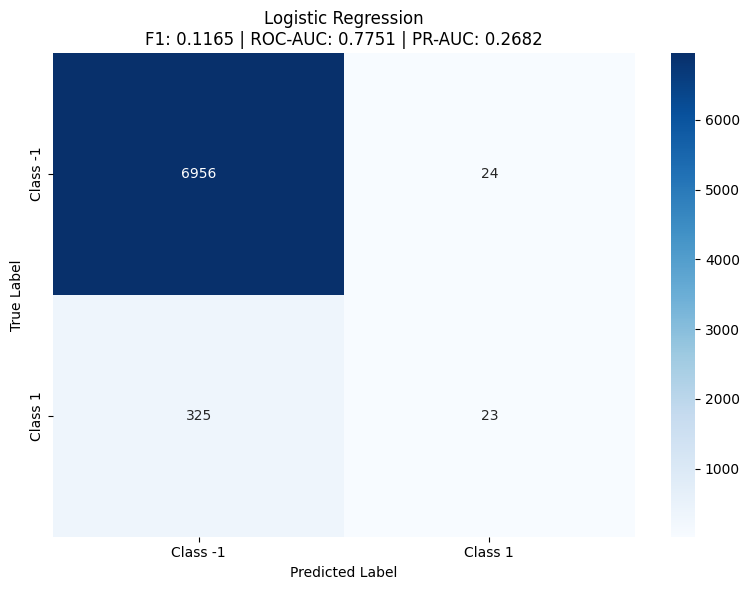

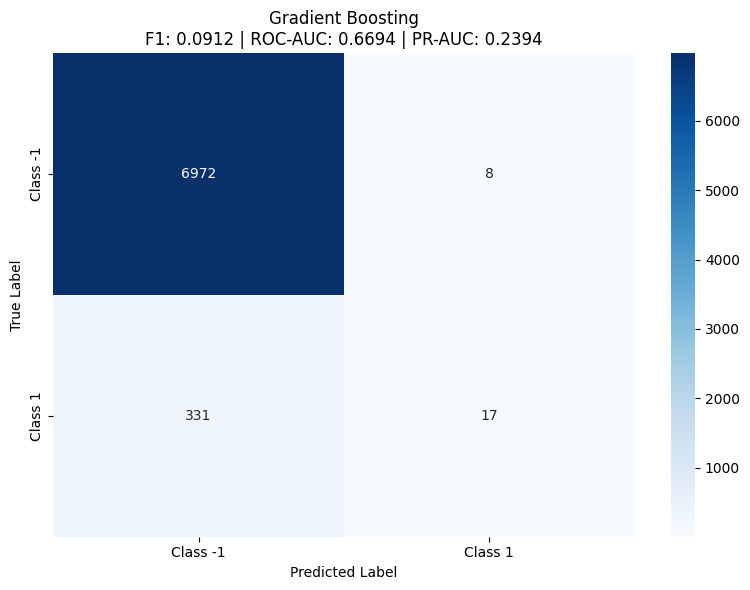

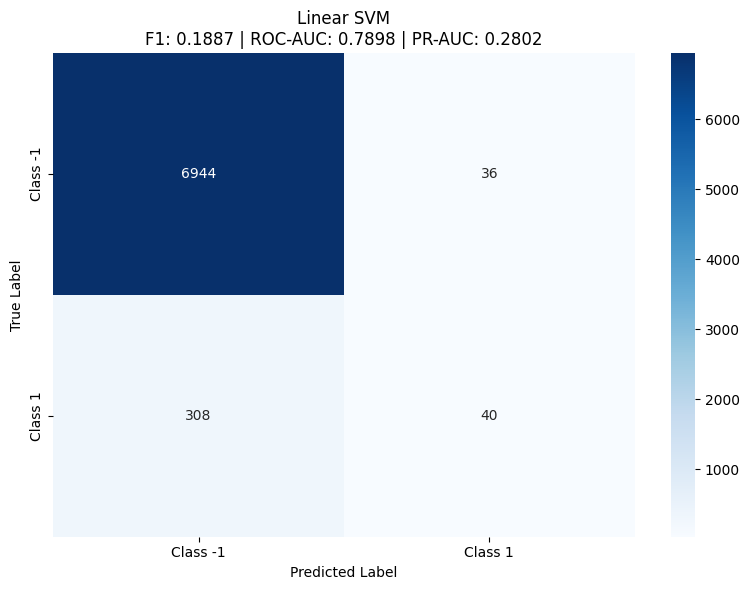

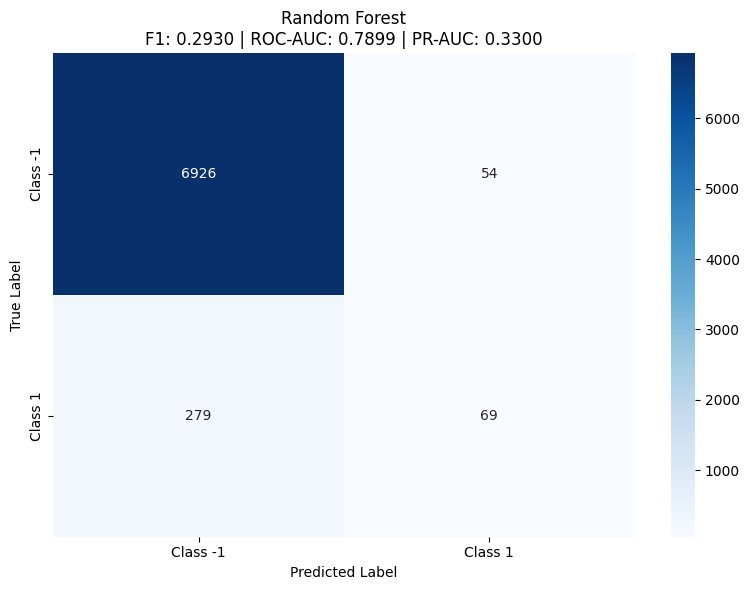

In [ ]:
from utils.evaluator import Evaluator
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
X_ML_train_scaled = scaler.fit_transform(X_ML_train)
X_ML_test_scaled = scaler.transform(X_ML_test)

# Model evaluation
evaluator = Evaluator(X_ML_train_scaled, y_ML_train, X_ML_test_scaled, y_test)
results_logistic_reg = evaluator.predict_logistic_regression()
print(results_logistic_reg)

results_gradient_boosting = evaluator.predict_gradient_boosting()
print(results_gradient_boosting)

results_svm = evaluator.predict_svm()
print(results_svm)

results_random_forest = evaluator.predict_random_forest()
print(results_random_forest)

In [ ]:
final_output = f"""
{results_logistic_reg}
{results_gradient_boosting}
{results_svm}
{results_random_forest}
"""

In [ ]:
import os
os.makedirs("results", exist_ok=True)

In [ ]:
end = timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"results_{start}_{end}.txt"

with open(f"results/{filename}", "w", encoding="utf-8") as f:
    f.write(final_output)

print(f"Saved results to {filename}")

Saved results to results_20260609_160757_20260609_161037.txt
